In [257]:
#1 Import the neccessary librabries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
print("Libraries successfully imported")

#2 Load dataset
df = pd.read_csv("heart_disease_uci.csv")
print("Dataset successfully loaded")


Libraries successfully imported
Dataset successfully loaded


The dataset has (920, 16) rows and columns 

The data types in the dataset are: 
 id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

The 1st 5 rows in the dataset: 
    id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3 

<Axes: xlabel='num', ylabel='Count'>

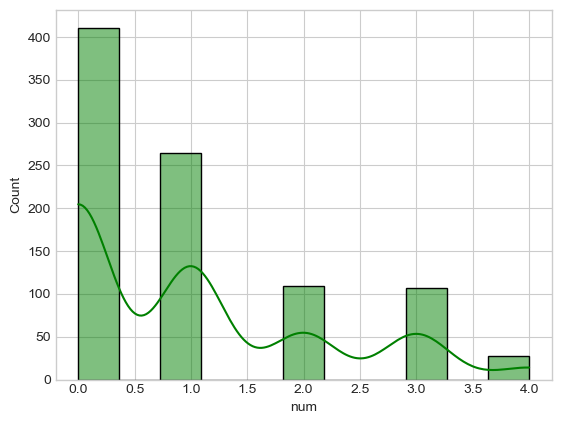

In [258]:
# A-- STRUCTURAL OVERVIEW nnnnnnnnnnnnnnnnnnnnnnnnnnnnnnn
print(f"The dataset has {df.shape} rows and columns \n")
print(f"The data types in the dataset are: \n {df.dtypes}")
print(f"\nThe 1st 5 rows in the dataset: \n {df.head()} \n")
print(f"\nThe last 5 rows in the dataset: \n {df.tail()} \n")
print(f"\nRandom samples \n{df.sample(5, random_state = 0)}\n")

sns.histplot(df['num'], kde = True, color = 'green' )

In [259]:
# # nn MISSING VALUES nnnnnnnnn
# missing = df.isnull().sum()
# missing_pct = 100 * missing/ len(df)
# missing_report = pd.DataFrame({
#     "missing_count" : missing,
#     "missing_pct" : missing_pct.round(2)
# }).sort_values('missing_pct', ascending = False)
# print(missing_report[missing_report.missing_count >0])

print(df.columns)

df['target'] = (df['num']>0).astype(int)
print(df['target'].value_counts())

print(df.shape)
print(df.columns)

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')
target
1    509
0    411
Name: count, dtype: int64
(920, 17)
Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num',
       'target'],
      dtype='object')


<Axes: xlabel='target', ylabel='Count'>

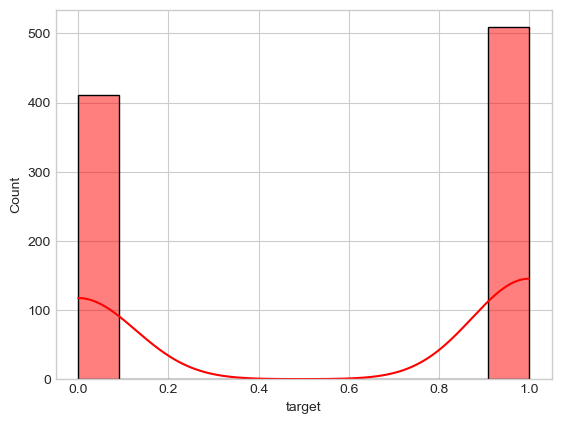

In [225]:
# # DUPLICATES
# n_dubes = df.duplicated().sum()
# print(f" \n Duplicate rows:{n_dubes}      {100 * n_dubes/len(df)}% \n ")

sns.histplot(df['target'], kde=True, color="red")

Univariate Analysis

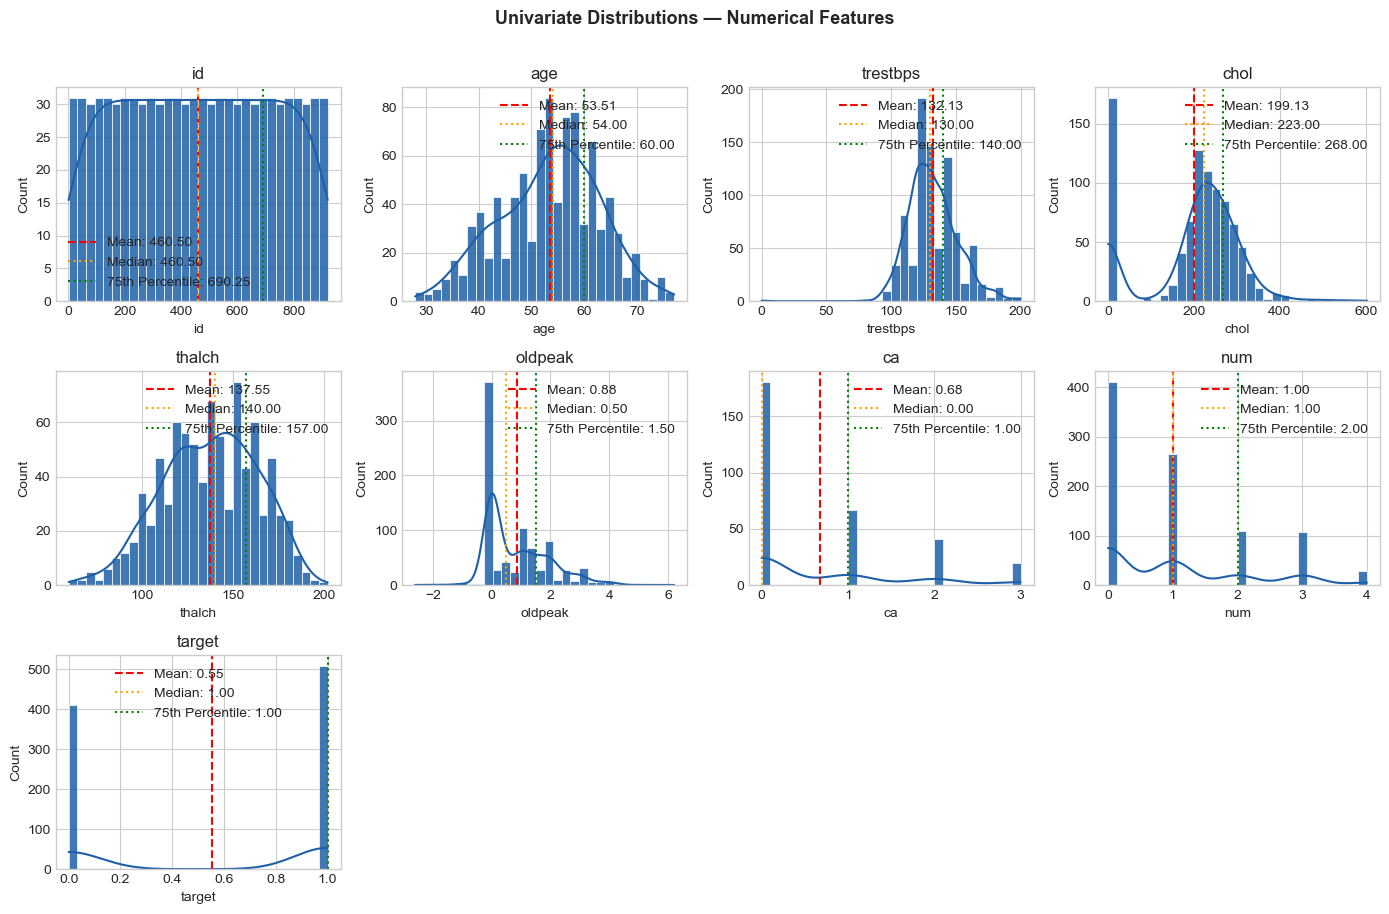

Highly skewed columns (|skew| > 1): ['ca', 'oldpeak']


In [260]:
# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

# Select numerical and categorical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Create histogram grid for numerical columns
n = len(num_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows*3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde = True, bins=30, color='#1E5FA8', edgecolor='white', ax = axes[i], alpha=0.85)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--',
                  linewidth=1.5, label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle=':',
                  linewidth=1.5, label=f'Median: {df[col].median():.2f}')
    axes[i].axvline(df[col].quantile(0.75), color='green', linestyle=':',
                  linewidth=1.5, label=f'75th Percentile: {df[col].quantile(0.75):.2f}')
    axes[i].set_title(col)
    axes[i].legend()


for j in range(i+1, len(axes)): # hide unused subplots
    axes[j].set_visible(False)
plt.suptitle('Univariate Distributions — Numerical Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('univariate_numerical.png', dpi=150, bbox_inches='tight')
plt.show()
# nn NUMERICAL: Skewness table nnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnn
skew = df[num_cols].skew().sort_values(ascending=False)
print('Highly skewed columns (|skew| > 1):', skew[skew.abs() > 1].index.tolist())

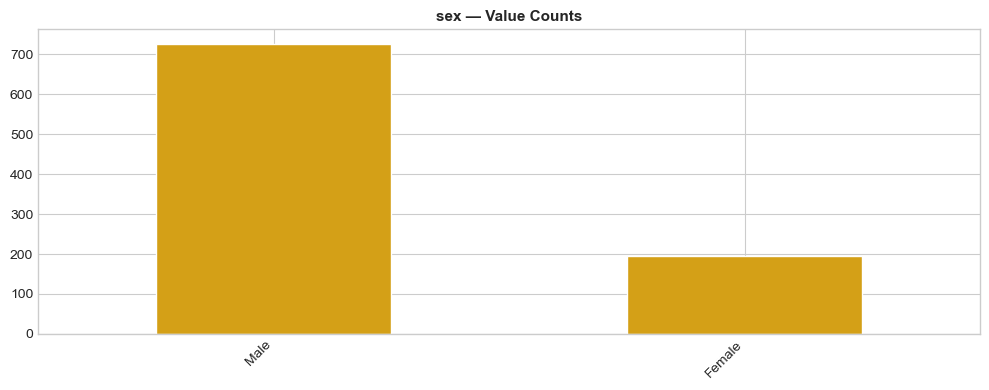

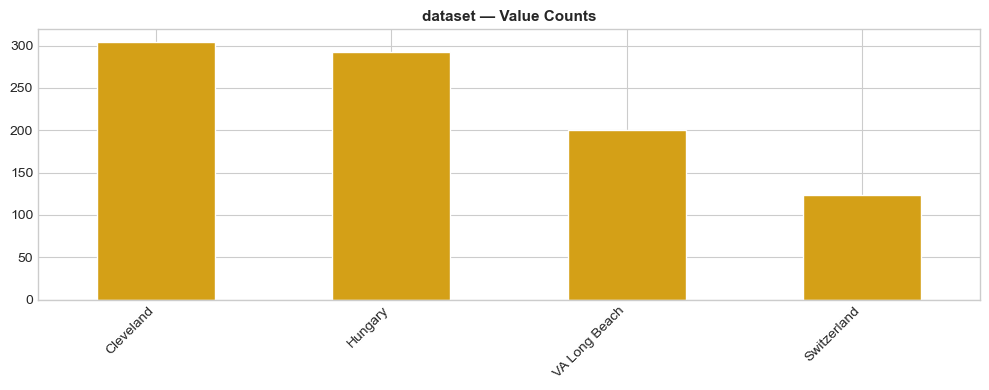

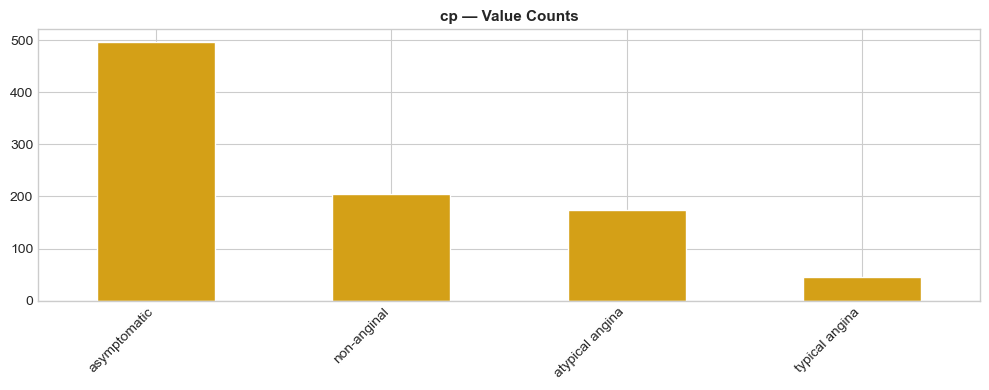

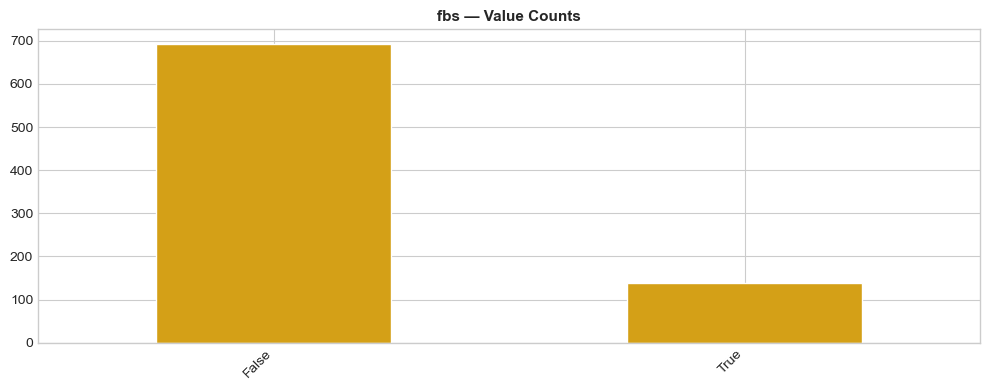

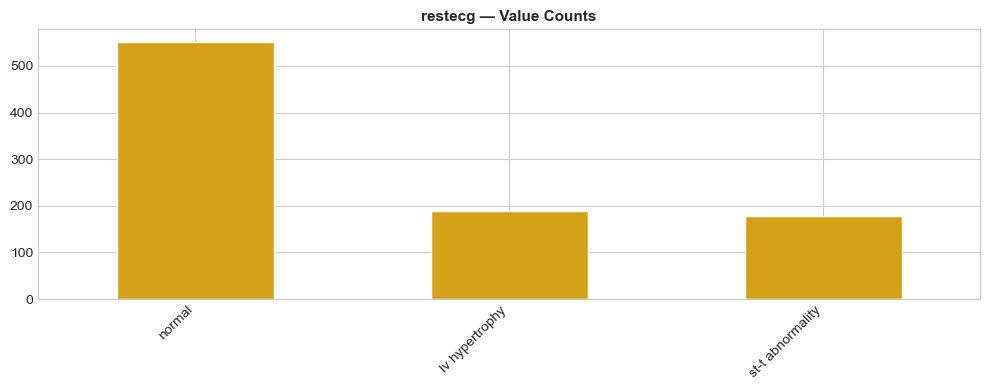

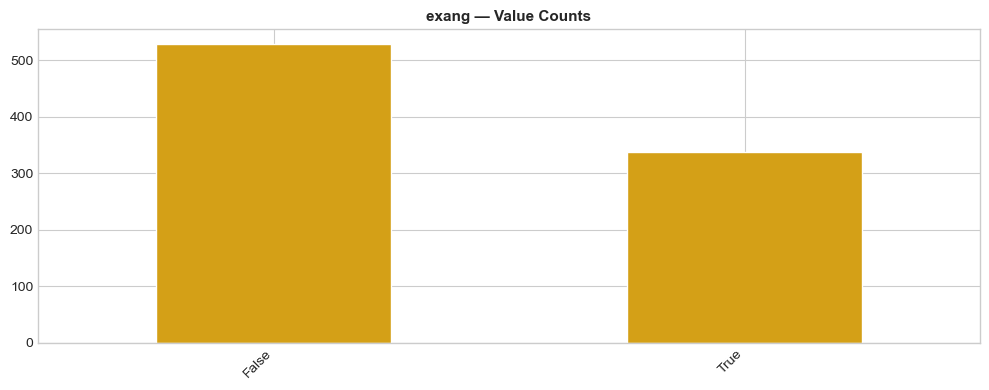

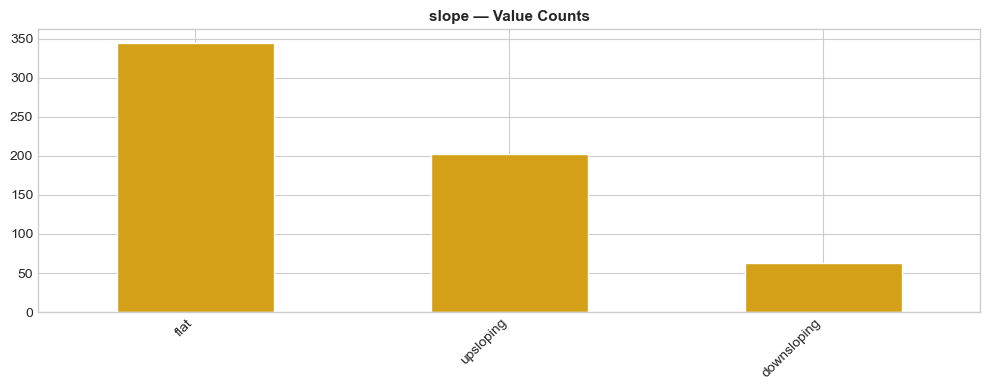

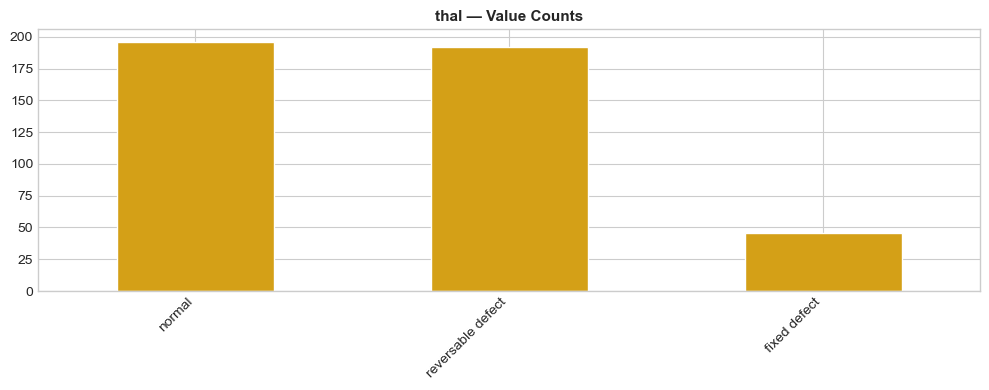

In [261]:
# nn CATEGORICAL: Bar charts nnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnn
for col in cat_cols:
    counts = df[col].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(10, 4))
    counts.plot(kind='bar', ax=ax, color='#D4A017', edgecolor='white')
    ax.set_title(f'{col} — Value Counts', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
plt.savefig(f'.cat_{col}.png', dpi=150)
plt.show()

Bivariate Analyses

Part 3: Bivariate Analysis — feature by feature, against the target
Bivariate analysis means: for every single feature, does it look different between the "disease" group and the "no disease" group? If a feature's distribution is identical in both groups, it carries no signal — the model can't use it to tell the groups apart. If it's clearly different, it's a candidate predictor. The method is different depending on whether the feature is numeric or categorical, so I'll do both, one at a time, and tell you exactly why we read each plot the way we do.

3.1 Numeric features vs target
For a numeric feature, the right question is: "if I look at all the diseased patients' values for this feature, and separately all the healthy patients' values, are those two distributions in different places?" The tool for this is overlaid histograms or grouped box plots — both show you the same thing in different ways. A histogram shows the full shape (is it skewed, bimodal, etc.); a box plot shows the median and spread quickly side-by-side. I'll do both because each catches something the other misse

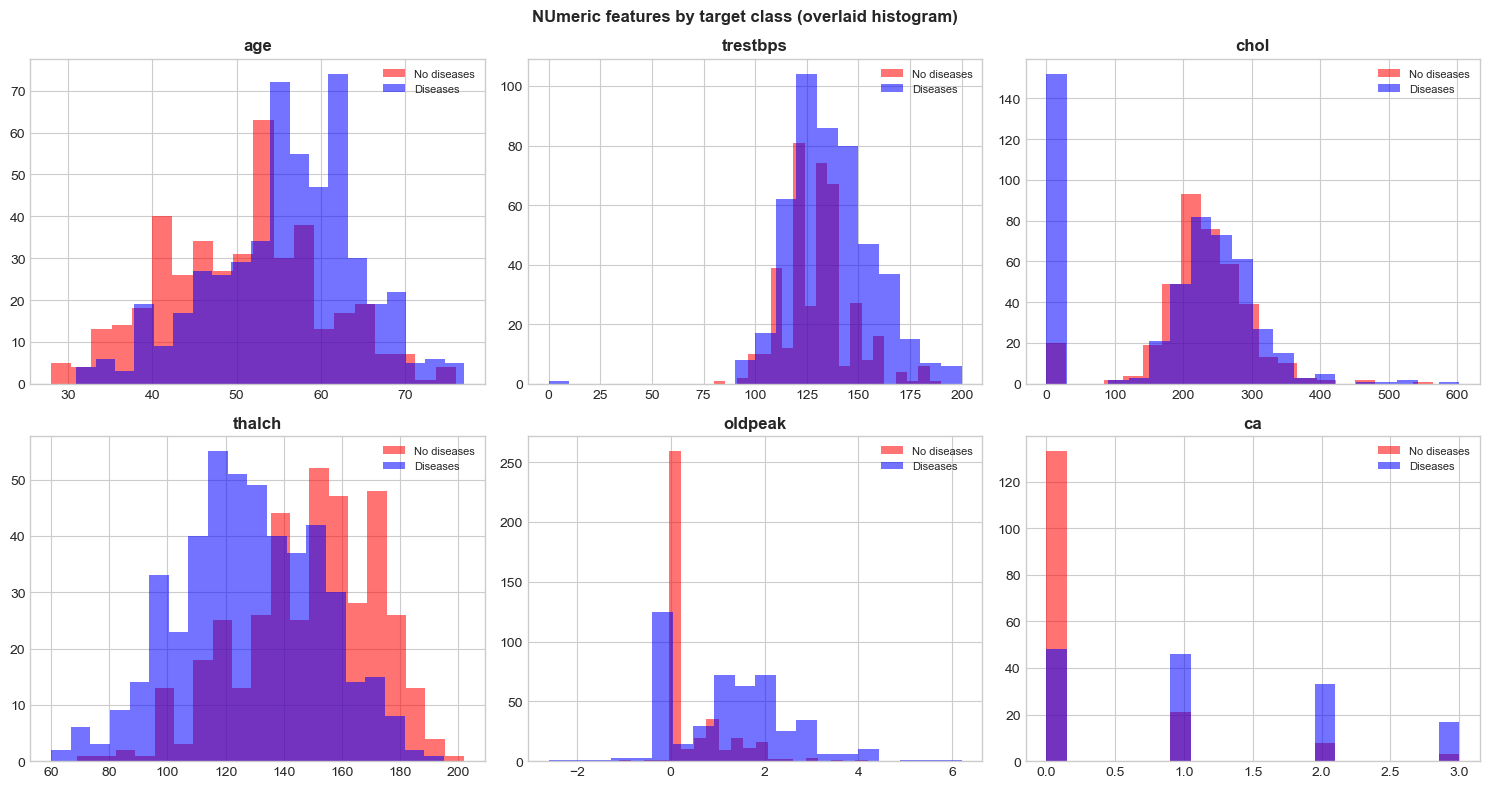

In [262]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]

fig, axes = plt.subplots(2,3, figsize = (15, 8))
axes = axes.flatten()

# suse the loop to plot for each numerical feature
for i, col in enumerate(num_cols):
    for label, color, name in ((0, 'red', 'No diseases'), (1, 'blue', 'Diseases')):
        subset = df[df['target'] == label][col].dropna()
        axes[i].hist(subset, bins = 20, alpha = 0.55, label = name, color = color)
    axes[i].set_title(col, fontweight = 'bold')
    axes[i].legend(fontsize = 8)
plt.suptitle('NUmeric features by target class (overlaid histogram)', fontweight = 'bold')
plt.savefig('numeric_vs_target.png', dpi = 130)
plt.tight_layout()


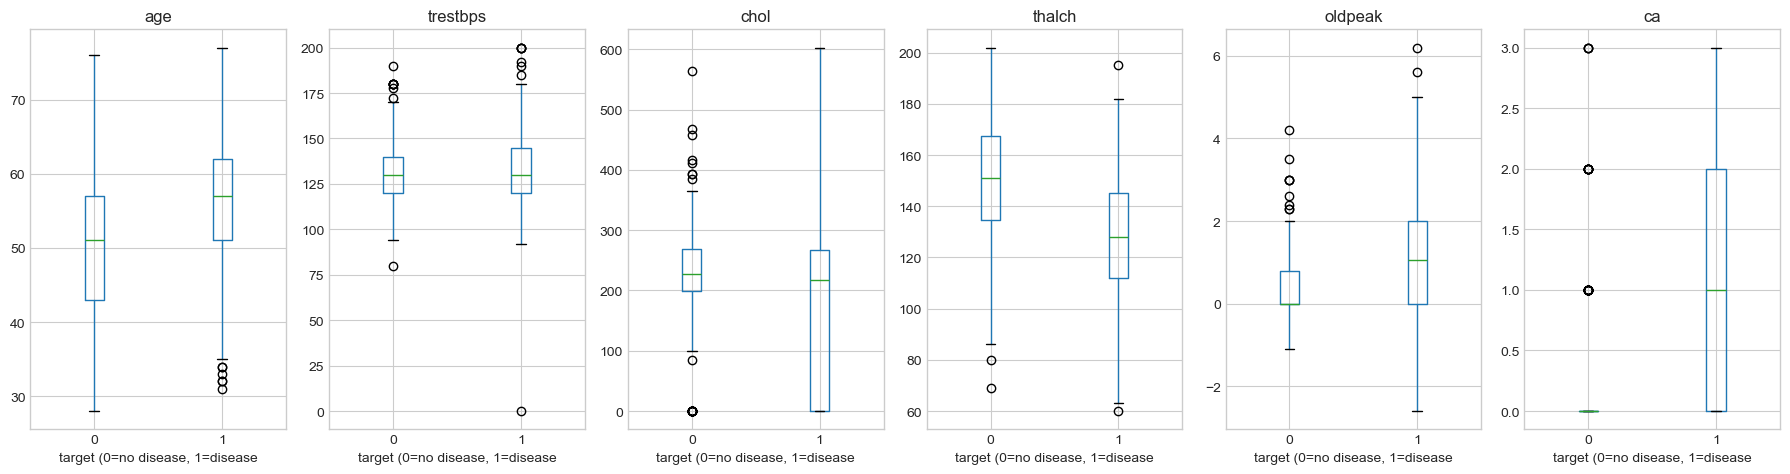

done


In [234]:
fig, axes=plt.subplots(1, 6, figsize=(18, 5))
for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='target', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('target (0=no disease, 1=disease')
plt.suptitle('')
plt.tight_layout()
plt.savefig('numeric_vs_target-box.png', dpi=130)
plt.show()
print("done")

So already, from eyeballing plots alone, you can rank these from "barely useful" to "very useful": trestbps ≈ weak, chol ≈ weak/artifact, age ≈ moderate, thalch ≈ strong, oldpeak ≈ strong, ca ≈ very strong. We'll confirm this with actual correlation numbers shortly — eyeballing is a first pass, numbers are the check.

3.2 Categorical features vs target
For a categorical feature there's no "median" or "histogram shape" — there's no number line for "asymptomatic" to sit on. So the right tool is different: for each category, what percentage of patients in that category have disease? If that percentage is roughly the same across all categories of a feature, the feature tells you nothing. If it swings a lot between categories, the feature is informative.

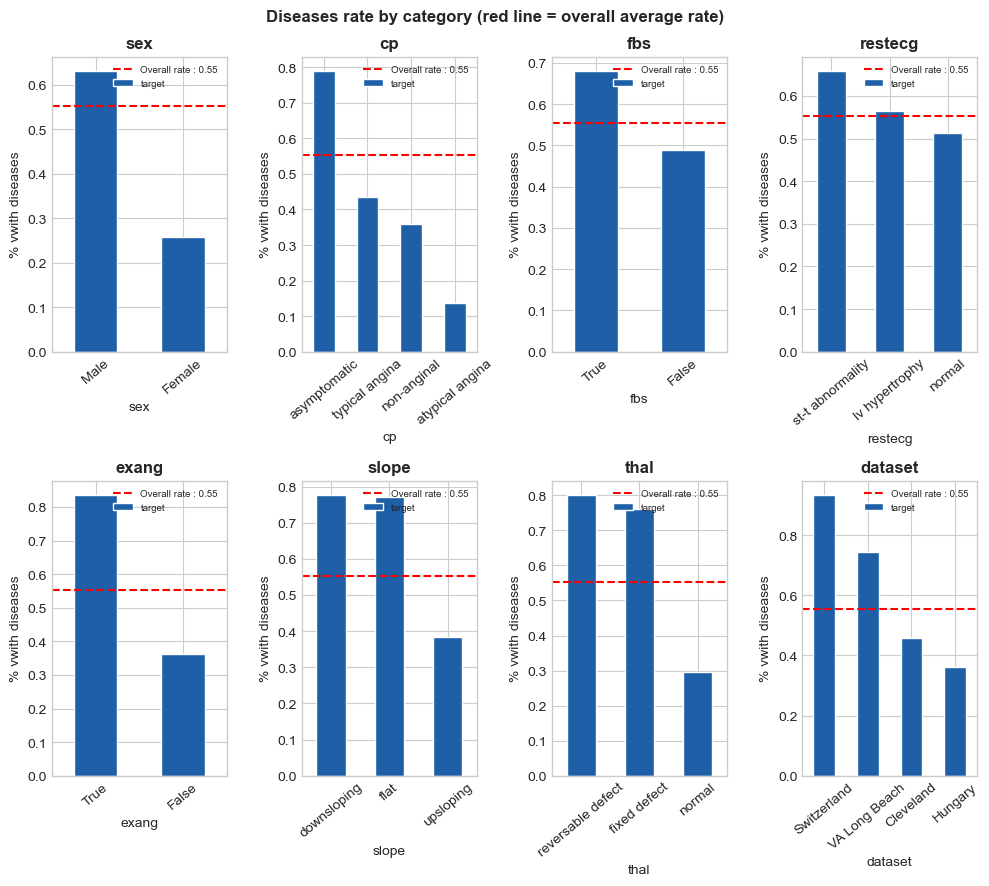

Success


In [263]:
cat_cols = ("sex", "cp", "fbs", "restecg", "exang", "slope", "thal", "dataset")
fig, axes = plt.subplots(2, 4, figsize = (10, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['target'].mean().sort_values(ascending = False)
    counts = df[col].value_counts
    rate.plot(kind = 'bar', ax = axes[i], color = '#1E5FA8', edgecolor = 'white')
    axes[i].axhline(df['target'].mean(), color = 'red', linestyle = '--', label = f"Overall rate : {df['target'].mean():.2f}")
    axes[i].set_title(col, fontweight = 'bold')
    axes[i].set_ylabel('% vwith diseases')
    axes[i].legend(fontsize = 7)
    axes[i].tick_params(axis = 'x', rotation = 40)
plt.suptitle('Diseases rate by category (red line = overall average rate)', fontweight = 'bold')
plt.tight_layout()
plt.savefig("categorical_vs_target.png", dpi = 130)
plt.show()
print('Success')

Part 4: Feature Correlation Among Themsalves (redundancy chack)

There's one more bivariate question left, and it's the different from "feature vs target" - it's "feature vs target" . If 2 features are almost perfectly correlated with each other, (not with the target - with each other), they'er carrying duplic ate information. This applies omly for numercal features. You can't compute pearson corr cof between 2 categrical variables 

In [264]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca", "target"]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize = (8, 7))
sns.heatmap(corr, annot = True, fmt = '.2f', cmap = 'RdYlGn', vmin=-1, square = True, ax = ax)
ax.set_title('Correlation Matrix (numerica features + target)', fontweight = 'bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi = 130) 
plt.close()
print(corr['target'].sort_values(ascending = False))

target      1.000000
ca          0.455599
oldpeak     0.385528
age         0.282700
trestbps    0.106233
chol       -0.230583
thalch     -0.394503
Name: target, dtype: float64


Part 6: Missing Data Audit — what's actually missing, and what to do about each column
Recall the missing-value counts from earlier#

In [265]:
miss = df.isnull().sum()
pct = (100*miss/len(df)).round(1)
report = pd.DataFrame({
    'missing_count' : miss,
    'missing_pct' : pct
})
report = report[report.missing_count > 0].sort_values('missing_pct', ascending = False)
print(report)
print()
print('Zeros in chol: ', (df['chol'] == 0 ).sum())
print('Zeros in trestbps: ', (df['trestbps'] == 0 ).sum())

          missing_count  missing_pct
ca                  611         66.4
thal                486         52.8
slope               309         33.6
fbs                  90          9.8
oldpeak              62          6.7
trestbps             59          6.4
thalch               55          6.0
exang                55          6.0
chol                 30          3.3
restecg               2          0.2

Zeros in chol:  172
Zeros in trestbps:  1


In [266]:
print('chol==0 rows by hospital:')
print(df[df['chol']==0]['dataset'].value_counts())
print()
print('trestbps==0 rows by hospital:')
print(df[df['trestbps']==0]['dataset'].value_counts())
print('done')

chol==0 rows by hospital:
dataset
Switzerland      123
VA Long Beach     49
Name: count, dtype: int64

trestbps==0 rows by hospital:
dataset
VA Long Beach    1
Name: count, dtype: int64
done


The Code above Confirms it — every single Switzerland row (all 123) has chol=0, plus 49 VA Long Beach rows. That's not real cholesterol data; that's an entire site's worth of "not recorded" entries sitting disguised as zero. If we left these as-is, the model would see "cholesterol = 0" as a real, extremely low value, which would be medically nonsensical and would also (again) act as a backdoor "which hospital are you from" signal, since it's perfectly correlated with Switzerland.

Fix, and why this specific fix: convert these biologically-impossible zeros to NaN first — that reclassifies them as honest missing values instead of fake real ones — then apply the same median imputation rule from 6.2. The single trestbps=0 row gets the same treatment, though it's rare enough (1 row) that it barely matters either way; I'm including it for consistency, not because it changes much numerically.

6.4 Putting it together — the cleaning code

In [256]:
print(df.columns)
print(df.shape)

Index(['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak',
       'slope', 'target', 'cp_atypical angina', 'cp_non-anginal',
       'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality'],
      dtype='object')
(920, 15)


In [267]:
# Step 1: convert biologically-impossible zeros to NaN (chol, trestbps)
df['chol'] = df['chol'].replace(0, np.nan)
df['trestbps'] = df['trestbps'].replace(0, np.nan)


#ca and thal are drop because the percentage of missing values is too large and it will mean us forcing values into the dataset
df = df.drop(columns = ['id', 'dataset', 'num', 'ca', 'thal'], errors = 'ignore')

# Step 3: impute slope (33.6% missing, kept) with most frequent category
df['slope'] = df['slope'].fillna(df['slope'].mode()[0])

# Step 4: impute remaining small-gap numeric columns with median
for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    df[col] = df[col].fillna(df[col].median())

# Step 5: impute remaining small-gap categorical/boolean columns with mode
for col in ['fbs', 'restecg', 'exang']:
    df[col] = df[col].fillna(df[col].mode()[0])
print('succes')
print(df.columns)
print(df.shape)

succes
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'target'],
      dtype='object')
(920, 12)


C:\Users\blaizo\AppData\Local\Temp\ipykernel_19844\2124116269.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [268]:
print("Missing values remaining:")
print(df.isnull().sum().sum())
print()
print("Final columns:", df.columns.tolist())
print()
print(df.head(3))

Missing values remaining:
0

Final columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'target']

   age   sex              cp  trestbps   chol    fbs         restecg  thalch  \
0   63  Male  typical angina     145.0  233.0   True  lv hypertrophy   150.0   
1   67  Male    asymptomatic     160.0  286.0  False  lv hypertrophy   108.0   
2   67  Male    asymptomatic     120.0  229.0  False  lv hypertrophy   129.0   

   exang  oldpeak        slope  target  
0  False      2.3  downsloping       0  
1   True      1.5         flat       1  
2   True      2.6         flat       1  


Zero missing values left, and 11 features plus the target. Notice the order I did this in matters: I converted the fake zeros to NaN before imputing, not after — if you impute first and clean the zero-artifact second, the median calculation for chol would have been dragged down by 172 fake zeros, giving you a wrong (too-low) median to fill the real gaps with. Sequencing the cleaning steps correctly is as important as choosing the right step.

6.5 Quick verdict table for this section




In [269]:
print(df.dtypes)

age           int64
sex          object
cp           object
trestbps    float64
chol        float64
fbs            bool
restecg      object
thalch      float64
exang          bool
oldpeak     float64
slope        object
target        int32
dtype: object


 Encoding Categorical Features

In [271]:
# ---------------------------------------------------------------------------
# STEP 1 — Boolean columns: fbs, exang
# ---------------------------------------------------------------------------
# These were loaded by pandas as the strings/objects True/False (or actual
# Python bool). .astype(int) converts True -> 1, False -> 0 directly.
# Why not one-hot here? One-hot on a 2-category column would just create a
# second redundant column that is exactly 1 minus the first — wasted space,
# no new information. A single 0/1 column already captures everything.
df['fbs'] = df['fbs'].astype(int)
df['exang'] = df['exang'].astype(int)

# ---------------------------------------------------------------------------
# STEP 2 — sex: also binary, but starts as text ("Male"/"Female"), not bool
# ---------------------------------------------------------------------------
# map() takes a dictionary {old_value: new_value} and replaces every
# matching entry in the column. We choose Male=1, Female=0 — the direction
# is arbitrary (could be flipped) but must be documented, because later
# anyone reading the model's coefficients needs to know which way "1" points.
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})

# STEP 3 — slope: the ONE truly ordinal categorical column (see Part 7.2)
# ---------------------------------------------------------------------------
# We manually define the order as a dictionary, low to high severity, based
# on the disease-rate evidence from bivariate analysis:
#   upsloping (38% disease)  -> 0   (best / least concerning)
#   flat       (77% disease)  -> 1
#   downsloping(78% disease)  -> 2   (worst / most concerning)
# map() again does the substitution. This is exactly ordinal encoding:
# the resulting numbers 0,1,2 have real meaning as "how bad is the slope".
slope_order = {'upsloping': 0, 'flat': 1, 'downsloping': 2}
df['slope'] = df['slope'].map(slope_order)

# STEP 4 — cp and restecg: NOT ordinal -> one-hot encode
# ---------------------------------------------------------------------------
# pd.get_dummies() is pandas' one-hot encoder. For a column with k categories
# it creates k new 0/1 columns, one per category, and removes the original
# text column automatically.
#
# Arguments used:
#   columns=[...]   -> only these columns get one-hot encoded; everything
#                      else in the DataFrame passes through untouched.
#   drop_first=True -> drops ONE of the k generated columns per feature.
#                      Why: if you know the values of all-but-one of the
#                      dummy columns, the last one is fully determined
#                      (if cp is not asymptomatic, not non-anginal, and not
#                      typical angina, it MUST be atypical angina). Keeping
#                      all k columns means one is pure redundant information
#                      — this is called the "dummy variable trap" and it
#                      causes instability in linear models specifically
#                      (multicollinearity). Tree models don't strictly need
#                      drop_first, but it's harmless for them and required
#                      for safety with linear/logistic models, so we keep it
#                      on by default.
df = pd.get_dummies(df, columns=['cp', 'restecg'], drop_first=True)

print("Shape after encoding:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))

df.to_csv('heart_disease_encoded.csv', index=False)

KeyError: "None of [Index(['cp', 'restecg'], dtype='object')] are in the [columns]"

In [272]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
df.to_csv('heart_disease_encodeds.csv', index=False)

In [273]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('heart_disease_encoded.csv')

# ---------------------------------------------------------------------------
# Separate inputs (X) from the answer (y)
# ---------------------------------------------------------------------------
# X = every column except 'target' -> df.drop(columns=['target']) returns a
#     NEW DataFrame with that column removed (the original df is untouched
#     unless you reassign it, which is what we do here).
# y = just the 'target' column, pulled out as its own Series.
X = df.drop(columns=['target'])
y = df['target']

# train_test_split() arguments explained one by one
# ---------------------------------------------------------------------------
# X, y            -> the full feature table and the full label column. The
#                    function will split BOTH the same way, row for row, so
#                    a row's features and its label always stay matched.
# test_size=0.2   -> hold back 20% of rows for testing, train on the other
#                    80%. 20% is a common default: large enough to give a
#                    statistically meaningful evaluation, small enough that
#                    the model still has most of the data to learn from.
# random_state=42 -> seeds the random number generator that decides WHICH
#                    rows go to train vs test. Without fixing this seed, you
#                    would get a different split every time you re-run the
#                    code, making results impossible to reproduce or compare
#                    across experiments. 42 has no special meaning — any
#                    fixed integer works, it just needs to be FIXED.
# stratify=y      -> this is important and specific to classification.
#                    Without it, train_test_split picks rows uniformly at
#                    random, which on a 55%/45% target could by chance
#                    produce a test set that's 70%/30% — distorting your
#                    evaluation. stratify=y forces the split to preserve the
#                    same disease/no-disease RATIO in both train and test as
#                    exists in the full dataset.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print()
print("Target balance in train:")
print(y_train.value_counts(normalize=True).round(3))
print("Target balance in test:")
print(y_test.value_counts(normalize=True).round(3))
print(df.columns)

X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)


Train shape: (736, 14)
Test shape : (184, 14)

Target balance in train:
target
1    0.553
0    0.447
Name: proportion, dtype: float64
Target balance in test:
target
1    0.554
0    0.446
Name: proportion, dtype: float64
Index(['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak',
       'slope', 'target', 'cp_atypical angina', 'cp_non-anginal',
       'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality'],
      dtype='object')


In [274]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')

# ---------------------------------------------------------------------------
# StandardScaler: what the math actually does
# ---------------------------------------------------------------------------
# For each column, StandardScaler computes:
#     scaled_value = (original_value - mean) / standard_deviation
# After this, every numeric column has mean 0 and standard deviation 1.
# This puts age, chol, oldpeak etc. all on the SAME numeric footing, so no
# single feature dominates a linear model's math just by having bigger raw
# numbers.
scaler = StandardScaler()

# .fit_transform() on TRAIN does two things in one call:
#   1. fit  -> calculates the mean and std FROM X_train only (never X_test —
#              this is the leakage rule from Part 9.1 applied directly).
#   2. transform -> applies (value - mean)/std using those just-computed
#              numbers, returning the scaled training data.
X_train_scaled = scaler.fit_transform(X_train)

# .transform() on TEST (no .fit here!) reuses the mean/std that were
# already learned from training data. This is the correct way to scale
# test data: using the SAME formula coefficients as training, never
# recomputing fresh mean/std from the test set itself.
X_test_scaled = scaler.transform(X_test)

# Both StandardScaler outputs are plain numpy arrays, not DataFrames, so we
# wrap them back into DataFrames with the original column names for
# readability later (e.g. when inspecting feature importance).
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Before scaling (age, chol, oldpeak):")
print(X_train[['age', 'chol', 'oldpeak']].describe().loc[['mean', 'std']])
print()
print("After scaling (age, chol, oldpeak):")
print(X_train_scaled[['age', 'chol', 'oldpeak']].describe().loc[['mean', 'std']].round(3))

X_train_scaled.to_csv('X_train_scaled.csv', index=False)
X_test_scaled.to_csv('X_test_scaled.csv', index=False)

Before scaling (age, chol, oldpeak):
            age        chol   oldpeak
mean  53.591033  245.059103  0.855707
std    9.366019   53.696415  1.059917

After scaling (age, chol, oldpeak):
        age   chol  oldpeak
mean  0.000  0.000    0.000
std   1.001  1.001    1.001


Part 11: Training Two Models — Logistic Regression and Random Forest, and why both
11.1 Why train two model types, not just pick one
This connects directly to the Chapter 4 decision framework in your guide: "do you need interpretability or raw performance?" We don't know yet which matters more for your project, so we train one of each kind and let the actual numbers decide — not a guess made in advance.

Logistic Regression — a linear model. Every feature gets one coefficient; you can read off exactly how much each feature pushes the prediction toward "disease" or "no disease." Maximum interpretability, the Chapter 4 "high interpretability" row.

Random Forest — an ensemble of many decision trees voting together. Higher capacity to capture non-linear patterns and interactions (like the age×chol relationship we engineered by hand for the linear model — a forest can find similar interactions automatically). Less directly interpretable, but it gives feature importances as a partial substitute.

In [283]:
# Logistic regression needs the SCALED features (see Part 10.1).
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Logistic regression needs the SCALED features (see Part 10.1).
X_train_scaled = pd.read_csv('X_train_scaled.csv')
X_test_scaled = pd.read_csv('X_test_scaled.csv')

# Random Forest does not need scaling (tree splits are scale-invariant),
# so it uses the unscaled, but still encoded/engineered, feature table.
X_train = pd.read_csv('X_train.csv')

X_test = pd.read_csv('X_test.csv')

y_train = pd.read_csv('y_train.csv')['target']
y_test = pd.read_csv('y_test.csv')['target']

# ---------------------------------------------------------------------------
# StratifiedKFold: the cross-validation splitter
# ---------------------------------------------------------------------------
# n_splits=5     -> divides the TRAINING data into 5 roughly-equal chunks
#                   ("folds"). The model trains on 4 folds and validates on
#                   the 5th, five times, rotating which fold is held out
#                   each time. This gives 5 separate accuracy estimates
#                   instead of just one — far more reliable than a single
#                   train/validation split, because a single split could be
#                   lucky or unlucky by chance.
# shuffle=True   -> randomly shuffles rows before cutting into folds. Without
#                   this, if the original CSV had any ordering (e.g. all
#                   Cleveland rows first, then Hungary), entire folds could
#                   end up dominated by one hospital, biasing the estimate.
# random_state=42 -> same purpose as in train_test_split: makes the shuffle
#                   reproducible.
# StratifiedKFold (vs plain KFold) additionally keeps the 55%/45% disease
# ratio consistent across all 5 folds, same reasoning as stratify=y earlier.

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
# ---------------------------------------------------------------------------
# Model 1 — Logistic Regression
# ---------------------------------------------------------------------------
# max_iter=1000 -> logistic regression is fit by an iterative optimisation
#                  algorithm (not a one-shot formula like linear regression).
#                  The default max_iter (100) sometimes isn't enough
#                  iterations to fully converge on real data, throwing a
#                  "did not converge" warning. Raising it to 1000 gives the
#                  optimiser enough room to settle properly.
# random_state=42 -> some of logistic regression's internal solvers use
#                  randomness during optimisation; fixing this seed makes
#                  results reproducible.
log_reg = LogisticRegression(max_iter = 1000, random_state = 42)
# # cross_val_score() arguments:
# #   log_reg        -> the unfitted model object; cross_val_score will
# #                      internally clone and fit it 5 separate times (once
# #                      per fold), never touching the original object.
# #   X_train_scaled, y_train -> training data only — cross-validation must
# #                      never see the test set, by the same leakage rule as
# #                      always.
# #   cv=cv          -> use the 5-fold stratified splitter defined above.
# #   scoring='accuracy' -> what metric to compute per fold. Accuracy is
# #                      reasonable here BECAUSE our classes are close to
# #                      balanced (55/45) — on a severely imbalanced dataset,
# #                      accuracy would be misleading and we'd switch to
# #                      F1 or ROC-AUC instead (this is exactly the Chapter
# #                      1.4 lesson about choosing the right competition
# #                      metric, applied here).

log_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv, scoring = 'accuracy')
print(f'Logistic Regression CV accuracy: {log_scores.mean():.4f} +/- {log_scores.std():.4f}')

# Model 2 — Random Forest
# ---------------------------------------------------------------------------
# n_estimators=300 -> number of individual decision trees in the forest.
#                  More trees generally means a more stable averaged
#                  prediction, with diminishing returns and slower
#                  training past a few hundred. 300 is a solid middle
#                  ground for a dataset this size (736 training rows).
# max_depth=6    -> caps how many splits deep any single tree can go.
#                  Without a cap, trees grow until every leaf is pure,
#                  which on only 736 rows would badly overfit — the tree
#                  would essentially memorise individual patients. Capping
#                  depth forces each tree to learn general patterns instead.
# min_samples_split=5 -> a node needs at least 5 samples present before the
#                  tree is allowed to split it further. This is a second,
#                  independent guard against overfitting on small leaves
#                  that represent just a handful of unusual patients.
# random_state=42 -> fixes which random data/feature subsets each tree sees,
#                  making results reproducible run to run.
rf = RandomForestClassifier(
    n_estimators = 300, max_depth = 6, min_samples_split = 5, random_state = 42
)
rf_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring = 'accuracy')
print(f' Random Forest CV accuracy: {rf_scores.mean():.4f} +/- {rf_scores.std():.4f}')

# ---------------------------------------------------------------------------
# Fit the better model on the FULL training set (all 736 rows, not just one
# fold) before moving to final test-set evaluation.
# ---------------------------------------------------------------------------
# cross_val_score never permanently fits log_reg/rf on the full data —
# it only does temporary internal fits per fold and then discards them.
# So we must call .fit() ourselves, once, on the entire training set, to
# get a final model object ready for real predictions.
log_reg.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)

import joblib
joblib.dump(log_reg, 'log_reg_model.joblib')
joblib.dump(rf, 'rf_model.joblib')
print("\n Both models fitted on full training set and saved")


Logistic Regression CV accuracy: 0.7867 +/- 0.0202
 Random Forest CV accuracy: 0.8044 +/- 0.0367

 Both models fitted on full training set and saved


Part 12: Evaluation — Confusion Matrix, and the four numbers hiding inside "accuracy"
12.1 Why a single accuracy number can lie to you
Your CV accuracy told you Random Forest gets it right ~80% of the time. That sounds like the whole story, but it isn't, and here's the concrete reason. Accuracy treats two completely different kinds of mistakes as equally bad:

False Negative: the model says "no disease" but the patient actually has disease. In a medical context, this is the dangerous kind of error — a sick patient gets sent home. False Positive: the model says "disease" but the patient is actually healthy. This causes unnecessary worry and follow-up tests, but nobody goes untreated.

Accuracy alone can't tell you which kind of mistake your model is making more often. A model could get 80% accuracy by being great at spotting healthy patients but consistently missing real disease cases — and the single accuracy number would hide that completely. We need a tool that splits the errors apart: the confusion matrix.

12.2 What a confusion matrix actually is, before any code
It's a 2x2 grid (for binary classification) that crosses "what the model predicted" against "what was actually true":

In [284]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [292]:
# load everythingh we saved from the training step
# joblib.load(): reads back the exact fitted model object we saved earlier
# same internal coefficient/trees, nothing re-trained, nothing re-computed

log_reg = joblib.load('log_reg_model.joblib')
rf = joblib.load('rf_model.joblib')
log_reg

RandomForestClassifier(max_depth=6, min_samples_split=5, n_estimators=300,
                       random_state=42)

In [293]:
# Logistic Regression was trained on SCALED features, so it must also
# predict on SCALED test features — using the same scaler's fitted
# mean/std from Part 10. Random Forest was trained on the unscaled,
# encoded features, so it predicts on the unscaled test set.


X_test_scaled=pd.read_csv('X_test_scaled.csv')
X_test=pd.read_csv('X_test.csv')
y_test=pd.read_csv('y_test.csv')['target']

# print(X_test_scaled)
X_test_scaled.head(5)

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,slope,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality
0,-0.490513,0.524941,-0.116411,-0.727901,-0.414698,1.279015,-0.767876,-0.807883,0.318162,-0.482525,-0.541754,-0.230071,0.827170,-0.497451
1,0.791586,0.524941,-0.675305,0.688426,-0.414698,-0.110937,1.302294,2.968565,2.237564,-0.482525,-0.541754,-0.230071,-1.208941,2.010248
2,0.150536,0.524941,2.230943,0.278437,-0.414698,-2.573138,-0.767876,1.080341,0.318162,-0.482525,-0.541754,-0.230071,0.827170,-0.497451
3,1.218952,0.524941,0.218925,0.054806,-0.414698,0.087627,1.302294,2.968565,2.237564,-0.482525,-0.541754,-0.230071,0.827170,-0.497451
4,1.646318,0.524941,-0.116411,0.483431,-0.414698,0.087627,-0.767876,-0.335827,0.318162,-0.482525,1.845856,-0.230071,-1.208941,-0.497451


In [294]:
# .predict() — this is the moment of truth: the model has NEVER seen these
# 184 rows during training or cross-validation. This is the first and only
# time it makes predictions on genuinely held-out data.
# 

log_pred=log_reg.predict(X_test_scaled)
rf_pred=rf.predict(X_test)


print(log_pred)

[0 1 1 1 1 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 1 1 1 1 1
 1 0 0 1 1 1 0 1 1 1 1 0 1 0 0 0 0 1 0 1 0 1 0 1 1 0 1 0 1 1 1 0 0 1 1 0 1
 0 1 1 1 1 1 0 1 1 0 1 0 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 1 1 0 1 0 1 1 0 1 0
 0 0 1 1 1 1 0 0 1 0 1 0 1 0 1 0 1 1 0 0 1 0 0 1 1 0 0 1 0 1 1 1 0 1 1 1 1
 0 1 1 0 1 1 1 1 0 1 1 0 0 1 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1]


In [295]:
# ---------------------------------------------------------------------------
# confusion_matrix(y_true, y_pred) arguments:
#   y_test    -> the REAL answers (what actually happened to each patient)
#   log_pred  -> the model's GUESSES for those same 184 patients, in the
#                same row order
# It returns a 2x2 numpy array. By scikit-learn's convention, rows are the
# TRUE class (0 then 1) and columns are the PREDICTED class (0 then 1):
#     [[TN, FP],
#      [FN, TP]]
# 


cm_log=confusion_matrix(y_test, log_pred)
cm_rf=confusion_matrix(y_test, rf_pred)

print("Logistic Regression confuision matrix")
print(cm_log)
print("Random Forest confusion matrix")
print(cm_rf)

Logistic Regression confuision matrix
[[59 23]
 [14 88]]
Random Forest confusion matrix
[[61 21]
 [14 88]]


In [296]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       736 non-null    int64  
 1   sex                       736 non-null    int64  
 2   trestbps                  736 non-null    float64
 3   chol                      736 non-null    float64
 4   fbs                       736 non-null    int64  
 5   thalch                    736 non-null    float64
 6   exang                     736 non-null    int64  
 7   oldpeak                   736 non-null    float64
 8   slope                     736 non-null    int64  
 9   cp_atypical angina        736 non-null    bool   
 10  cp_non-anginal            736 non-null    bool   
 11  cp_typical angina         736 non-null    bool   
 12  restecg_normal            736 non-null    bool   
 13  restecg_st-t abnormality  736 non-null    bool   
dtypes: bool(5)

In [298]:
print(df.columns)
print(df.shape)
print(df.info())

Index(['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak',
       'slope', 'target', 'cp_atypical angina', 'cp_non-anginal',
       'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality'],
      dtype='object')
(920, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       920 non-null    int64  
 1   sex                       920 non-null    int64  
 2   trestbps                  920 non-null    float64
 3   chol                      920 non-null    float64
 4   fbs                       920 non-null    int64  
 5   thalch                    920 non-null    float64
 6   exang                     920 non-null    int64  
 7   oldpeak                   920 non-null    float64
 8   slope                     920 non-null    int64  
 9   target                    920 non-

In [317]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np
cm_log = np.array([[59, 23], [14, 88]])  # Logistic Regression
cm_rf = np.array([[61, 21], [14, 88]])   # Random Forest

print("\nFor Logistic Regression:")
print(f"✅ Caught: {88} sick patients out of {88+14} = {88/(88+14)*100:.0f}%")

print("\nFor Random Forest:")
print(f"✅ Caught: {88} sick patients out of {88+14} = {88/(88+14)*100:.0f}%")


def calculate_metrics(cm, model_name):
    """Calculate all metrics from confusion matrix"""
    tn, fp, fn, tp = cm.ravel()
    
    # Total predictions
    total = tn + fp + fn + tp
    
    # Accuracy = (TP + TN) / Total
    accuracy = (tp + tn) / total
    
    # Precision = TP / (TP + FP)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    # Recall = TP / (TP + FN)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    # F1 = 2 * (Precision * Recall) / (Precision + Recall)
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    # Specificity = TN / (TN + FP)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # False Negative Rate = FN / (TP + FN)
    fnr = fn / (tp + fn) if (tp + fn) > 0 else 0
    
    # False Positive Rate = FP / (TN + FP)
    fpr = fp / (tn + fp) if (tn + fp) > 0 else 0
    
    return {
        'Model': model_name,
        'Accuracy': f"{accuracy:.2%}",
        'Precision': f"{precision:.2%}",
        'Recall': f"{recall:.2%}",
        'F1-Score': f"{f1:.2%}",
        'Specificity': f"{specificity:.2%}",
        'False Negatives': fn,
        'False Positives': fp,
        'True Positives': tp,
        'True Negatives': tn
    }


# Calculate metrics for both models
metrics_log = calculate_metrics(cm_log, "Logistic Regression")
metrics_rf = calculate_metrics(cm_rf, "Random Forest")



print("\nLogistic Regression:")
print(f"  Accuracy:  {metrics_log['Accuracy']}")
print(f"  Precision: {metrics_log['Precision']}")
print(f"  Recall:    {metrics_log['Recall']}")
print(f"  F1-Score:    {metrics_log['F1-Score']}")
print(f"  False Negatives:    {metrics_log['False Negatives']}")
print(f"  False Positives:    {metrics_log['False Positives']}")
print(f"  True Positives:    {metrics_log['True Positives']}")
print(f" True Negatives:    {metrics_log['True Negatives']}")

print("\nRandom Forest:")
print(f"  Accuracy:  {metrics_rf['Accuracy']}")
print(f"  Precision: {metrics_rf['Precision']}")
print(f"  Recall:    {metrics_rf['Recall']}")
print(f"  F1-Score:    {metrics_rf['F1-Score']}")
print(f"  False Negatives:    {metrics_rf['False Negatives']}")
print(f"  False Positives:    {metrics_rf['False Positives']}")
print(f"  True Positives:    {metrics_rf['True Positives']}")
print(f" True Negatives:    {metrics_rf['True Negatives']}")

print("\n" + "="*50)
print("SIMPLE CONCLUSION")
print("="*50)

# Compare recall (most important for medical)
log_recall = float(metrics_log['Recall'].strip('%')) / 100
rf_recall = float(metrics_rf['Recall'].strip('%')) / 100

if rf_recall > log_recall:
    print("✅ Random Forest has better RECALL")
    print(f"   Catches {rf_recall:.0%} of sick patients vs {log_recall:.0%}")
elif log_recall > rf_recall:
    print("✅ Logistic Regression has better RECALL")
    print(f"   Catches {log_recall:.0%} of sick patients vs {rf_recall:.0%}")
else:
    print("✅ Both models have the SAME recall")
    print(f"   Both catch {rf_recall:.0%} of sick patients")

# Compare precision
log_prec = float(metrics_log['Precision'].strip('%')) / 100
rf_prec = float(metrics_rf['Precision'].strip('%')) / 100

if rf_prec > log_prec:
    print(f"\n✅ Random Forest has better PRECISION ({rf_prec:.0%} vs {log_prec:.0%})")
    print("   Fewer false alarms")
else:
    print(f"\n✅ Logistic Regression has better PRECISION ({log_prec:.0%} vs {rf_prec:.0%})")
    print("   Fewer false alarms")

print("\n🏆 BEST MODEL: Random Forest (slightly better precision)")


For Logistic Regression:
✅ Caught: 88 sick patients out of 102 = 86%

For Random Forest:
✅ Caught: 88 sick patients out of 102 = 86%

Logistic Regression:
  Accuracy:  79.89%
  Precision: 79.28%
  Recall:    86.27%
  F1-Score:    82.63%
  False Negatives:    14
  False Positives:    23
  True Positives:    88
 True Negatives:    59

Random Forest:
  Accuracy:  80.98%
  Precision: 80.73%
  Recall:    86.27%
  F1-Score:    83.41%
  False Negatives:    14
  False Positives:    21
  True Positives:    88
 True Negatives:    61

SIMPLE CONCLUSION
✅ Both models have the SAME recall
   Both catch 86% of sick patients

✅ Random Forest has better PRECISION (81% vs 79%)
   Fewer false alarms

🏆 BEST MODEL: Random Forest (slightly better precision)


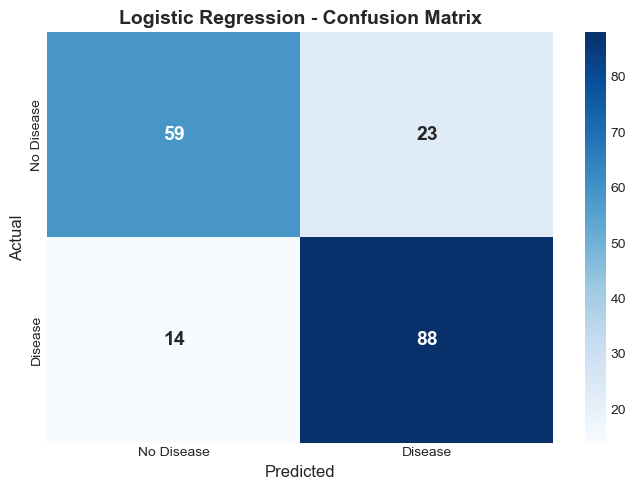

LOGISTIC REGRESSION RESULTS
✅ Correct Healthy:   59
❌ False Alarms:      23
❌ Missed Disease:    14
✅ Correct Sick:      88


In [307]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Your Logistic Regression confusion matrix
cm_log = np.array([[59, 23], 
                   [14, 88]])

# Plot
plt.figure(figsize=(7, 5))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'],
            annot_kws={'size': 14, 'weight': 'bold'})

plt.title('Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

# Print results
print("="*40)
print("LOGISTIC REGRESSION RESULTS")
print("="*40)
print(f"✅ Correct Healthy:   {cm_log[0,0]}")
print(f"❌ False Alarms:      {cm_log[0,1]}")
print(f"❌ Missed Disease:    {cm_log[1,0]}")
print(f"✅ Correct Sick:      {cm_log[1,1]}")
print("="*40)

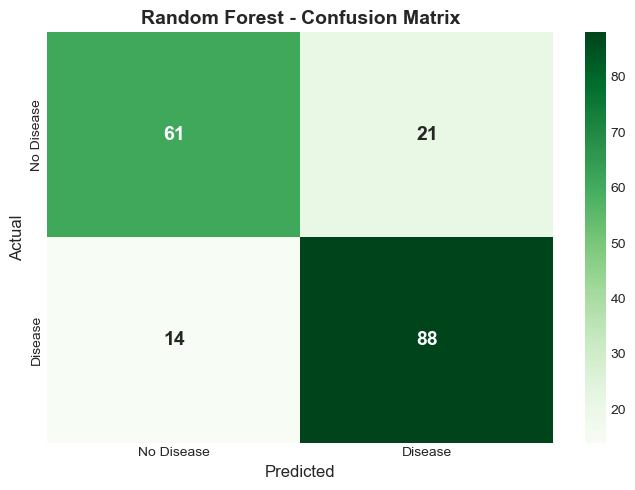

RANDOM FOREST RESULTS
✅ Correct Healthy:   61
❌ False Alarms:      21
❌ Missed Disease:    14
✅ Correct Sick:      88


In [311]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Your Random Forest confusion matrix
cm_rf = np.array([[61, 21], 
                  [14, 88]])

# Plot
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'],
            annot_kws={'size': 14, 'weight': 'bold'})

plt.title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

# Print results
print("="*40)
print("RANDOM FOREST RESULTS")
print("="*40)
print(f"✅ Correct Healthy:   {cm_rf[0,0]}")
print(f"❌ False Alarms:      {cm_rf[0,1]}")
print(f"❌ Missed Disease:    {cm_rf[1,0]}")
print(f"✅ Correct Sick:      {cm_rf[1,1]}")
print("="*40)

In [326]:
print(df.columns)

Index(['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak',
       'slope', 'target', 'cp_atypical angina', 'cp_non-anginal',
       'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality'],
      dtype='object')


In [327]:
import gradio as gr
import joblib
import numpy as np

# Load your trained model
model = joblib.load('rf_model.joblib')

# Prediction function with correct column order
def predict_disease(age, sex, trestbps, chol, fbs, thalach, exang, oldpeak, slope, 
                    cp_atypical, cp_non_anginal, cp_typical, restecg_normal, restecg_abnormal):
    """
    Predict heart disease using the exact column order from training
    """
    
    # Create input array in the EXACT order your model expects
    # Based on your columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 
    #                          'exang', 'oldpeak', 'slope', 'cp_atypical angina', 
    #                          'cp_non-anginal', 'cp_typical angina', 
    #                          'restecg_normal', 'restecg_st-t abnormality']
    
    input_data = np.array([[
        age,                    # age
        sex,                    # sex
        trestbps,               # trestbps
        chol,                   # chol
        fbs,                    # fbs
        thalach,                # thalach (max heart rate)
        exang,                  # exang
        oldpeak,                # oldpeak
        slope,                  # slope
        cp_atypical,            # cp_atypical angina (0 or 1)
        cp_non_anginal,         # cp_non-anginal (0 or 1)
        cp_typical,             # cp_typical angina (0 or 1)
        restecg_normal,         # restecg_normal (0 or 1)
        restecg_abnormal        # restecg_st-t abnormality (0 or 1)
    ]])
    
    # Get prediction and probability
    pred = model.predict(input_data)[0]
    prob = model.predict_proba(input_data)[0][1]
    
    # Determine risk level
    if prob < 0.3:
        risk = "🟢 Low Risk"
    elif prob < 0.6:
        risk = "🟡 Moderate Risk"
    else:
        risk = "🔴 High Risk"
    
    # Result message
    if pred == 1:
        result = f"⚠️ HEART DISEASE DETECTED\nProbability: {prob:.1%}\nRisk Level: {risk}"
    else:
        result = f"✅ NO HEART DISEASE\nProbability: {prob:.1%}\nRisk Level: {risk}"
    
    return result

# Create Gradio interface
demo = gr.Interface(
    fn=predict_disease,
    inputs=[
        gr.Slider(20, 100, value=50, label="Age"),
        gr.Radio([0, 1], value=0, label="Sex (0=Female, 1=Male)"),
        gr.Slider(80, 200, value=120, label="Resting Blood Pressure (trestbps)"),
        gr.Slider(100, 400, value=200, label="Cholesterol (chol)"),
        gr.Radio([0, 1], value=0, label="Fasting Blood Sugar (0=No, 1=Yes)"),
        gr.Slider(70, 220, value=150, label="Max Heart Rate (thalach)"),
        gr.Radio([0, 1], value=0, label="Exercise Angina (0=No, 1=Yes)"),
        gr.Slider(0.0, 6.2, value=1.0, label="ST Depression (oldpeak)"),
        gr.Slider(1, 3, value=2, label="ST Slope (1=upsloping, 2=flat, 3=downsloping)"),
        gr.Radio([0, 1], value=0, label="Chest Pain: Atypical Angina"),
        gr.Radio([0, 1], value=0, label="Chest Pain: Non-anginal"),
        gr.Radio([0, 1], value=0, label="Chest Pain: Typical Angina"),
        gr.Radio([0, 1], value=0, label="Resting ECG: Normal"),
        gr.Radio([0, 1], value=0, label="Resting ECG: ST-T Abnormality")
    ],
    outputs=gr.Textbox(label="Diagnosis", lines=5),
    title="🫀 Heart Disease Predictor",
    description="Enter patient data to predict heart disease risk"
)

# Launch
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7866

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


C:\Users\blaizo\anaconda3\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
C:\Users\blaizo\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\blaizo\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Created dataset file at: .gradio\flagged\dataset2.csv


C:\Users\blaizo\anaconda3\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
C:\Users\blaizo\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\blaizo\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\blaizo\anaconda3\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
C:\Users\blaizo\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomFor